In [6]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import librosa
import json

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 20,
})

In [2]:
def to_spectogram(file: str):
    y, sr = librosa.load(file, sr=None)

    S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=128)
    S_mel_db = librosa.power_to_db(np.abs(S_mel), ref=S_mel.max())
    return S_mel_db

In [3]:
path = "../outputs/results/TTS/"
jsons = glob(path + "/**/**/**/*.json")
gt, best = glob(path + "/**/ground_truth.wav", recursive=True), glob(path + "/**/best_*.wav", recursive=True)

In [4]:
sentences = [11,68,93]


Sentence:  11
Original Sentence:
	The boy was there when the sun rose
Final Sentence:
	The people who was there were the sunrobes

Sentence:  68
Original Sentence:
	This is a grand season for Hikes on the Road
Final Sentence:
	This is a grand Caesar for Heiks on the road

Sentence:  93
Original Sentence:
	A pound of sugar costs more than eggs
Final Sentence:
	A town of Shubber costs more than eggs


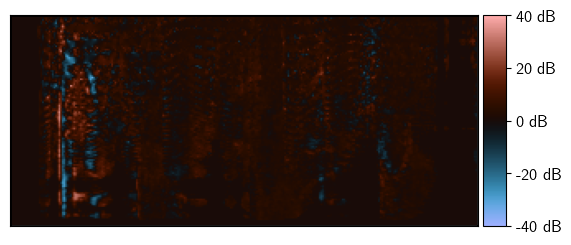

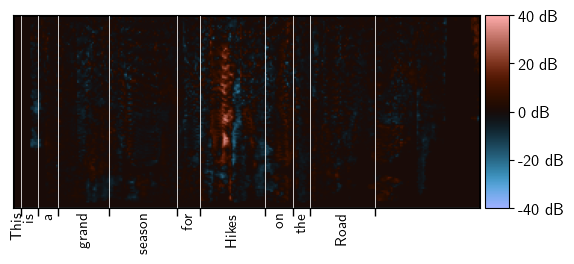

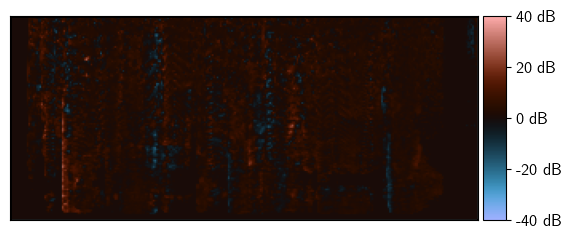

In [51]:
bounds =  [[], [0, 0.01818, 0.05455, 0.09697, 0.20606, 0.35152, 0.4, 0.53939, 0.6, 0.63636, 0.77576], []] # can be manually annotated using mark_word_boundaries.py
for i, s in enumerate(sentences):
    print("\nSentence: ", s)
    jsonf = [j for j in jsons if f"sentence_{s:03d}" in j][0]
    gsel = [e for e in gt if f"sentence_{s:03d}" in e][0]
    bsel = [e for e in best if f"sentence_{s:03d}" in e][0]
    with open(jsonf, "r") as f:
        data = json.load(f)
    print("Original Sentence:")
    gsentence = data["text_data"]["gt_transcription"]
    print(f"\t{gsentence}")
    print("Final Sentence:")
    print(f"\t{data['text_data']['asr_transcription']}")

    gspec, bspec = to_spectogram(gsel), to_spectogram(bsel)
    img = bspec - gspec
    h, w = img.shape[:2]

    gboundaries = [b*w for b in bounds[i]]
    gcenters = [0.5*(v1+v2) for v1,v2 in zip(gboundaries[:-1], gboundaries[1:])]


    fig, ax = plt.subplots(1,1)
    norm = TwoSlopeNorm(vmin=-40, vcenter=0, vmax=40)
    im = ax.imshow(img, cmap="berlin", norm=norm)
    ax.yaxis.set_visible(False)


    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)

    cbar = plt.colorbar(im, cax=cax)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f} dB"))

    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)
    rect = Rectangle((0, 0), w, h, linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(rect)

    if len(gcenters) > 0:
        ax.set_xticks(gcenters, minor=True)
        ax.set_xticklabels(gsentence.split(), minor=True, ha="center", fontsize=11, rotation=90)

        ax.set_xticks(gboundaries[1:], minor=False)
        ax.vlines(gboundaries[1:], 0, h, color="white", alpha=0.8, linewidth=0.7)
        ax.set_xticklabels([""] * (len(gboundaries)-1))
        ax.tick_params(axis="x", which="major", length=6, width=1)
        ax.tick_params(axis="x", which="minor", bottom=False, top=False, length=0)
    else:
        ax.xaxis.set_visible(False)

    plt.savefig(f"_figures/qual_sentence_{s}.jpg", dpi=200, bbox_inches="tight")
